<h1>Anomaly detection<h1>

In [1]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
from scipy.io import loadmat  
 
 
data = loadmat('ex8data1.mat')  
X = data['X']   

Text(0.5, 1.0, 'y axis')

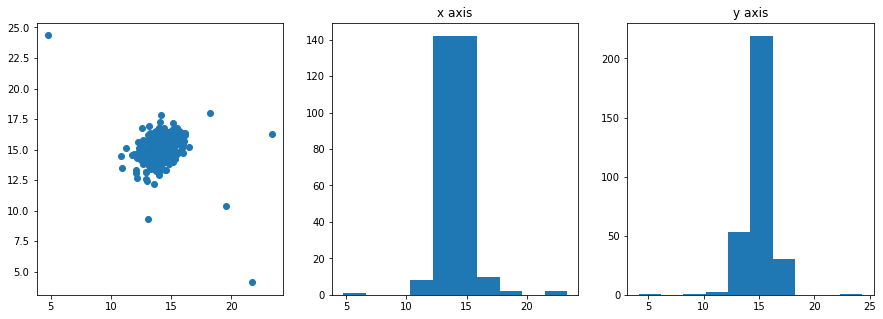

In [2]:
X.shape
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.scatter(X[:,0],X[:,1])
plt.subplot(1,3,2)
plt.hist(X[:,0])
plt.title('x axis')
plt.subplot(1,3,3)
plt.hist(X[:,1])
plt.title('y axis')

<h1>Gaussian distribution<h1>


In [13]:
def estimate_gaussian(X):  
    mu=np.mean(X.T,axis=1)
    sigma=np.std(X.T,axis=1)
 
# TODO: calculate mu and sigma
    return mu, sigma
 
# TODO: run the function for your dataset
# print(estimate_gaussian(X[:,0]))
# print(estimate_gaussian(X[:,1]))
mean,dev=estimate_gaussian(X)
print(mean,dev)


[14.11222578 14.99771051] [1.35374717 1.3075723 ]


<h1>Calculate probability<h1>

In [11]:
Xval = data['Xval']  
yval = data['yval']
 
# TODO: check the number of data (X.shape)
print(Xval.shape)
print(yval.shape)

(307, 2)
(307, 1)


In [16]:
from scipy import stats
# TODO: calculate the probability for X data
p=stats.norm.pdf(X,loc=mean,scale=dev)
print(p[:50,0])

[0.21620977 0.25745208 0.29413223 0.24721192 0.27251547 0.2918119
 0.18713958 0.15117648 0.09356331 0.166609   0.29338708 0.29448769
 0.25559237 0.25595621 0.2932714  0.2944456  0.29288017 0.28518331
 0.27727759 0.09489765 0.27027271 0.29342161 0.24110555 0.29304288
 0.19607729 0.15652979 0.27590459 0.25749622 0.27667047 0.2834953
 0.17068283 0.29318613 0.20432637 0.19577297 0.10897052 0.24595126
 0.14063746 0.29463374 0.28052751 0.29371857 0.28168158 0.22524293
 0.28218942 0.29429662 0.26674962 0.28856013 0.11137104 0.29467721
 0.28904196 0.18556585]


In [21]:
pval = np.zeros((Xval.shape[0], Xval.shape[1]))  
# TODO: calculate the probability for Xval data
pval[:,0] = stats.norm.pdf(Xval[:,0],loc=mean[0],scale=dev[0]) 
pval[:,1] = stats.norm.pdf(Xval[:,1],loc=mean[1],scale=dev[1]) 
print(pval)

[[1.36688038e-01 3.04577250e-01]
 [2.77272653e-01 2.95409626e-01]
 [2.52387437e-01 1.61322525e-01]
 [2.73146659e-01 2.26618293e-01]
 [2.62778656e-01 2.70900066e-01]
 [2.03711020e-01 2.08307264e-01]
 [1.99132113e-01 3.02316122e-01]
 [2.91026337e-01 2.88751221e-01]
 [7.95117869e-02 2.65241551e-01]
 [2.53066098e-01 3.04262360e-01]
 [2.76941891e-01 2.88628756e-01]
 [1.40516190e-01 3.03463058e-01]
 [2.10596140e-01 2.51500509e-01]
 [9.82402034e-02 1.48224691e-01]
 [2.58184982e-01 2.10447722e-01]
 [1.92526120e-01 2.28745285e-01]
 [1.74868919e-01 2.49576082e-01]
 [1.89375290e-01 3.01093208e-01]
 [2.87820926e-01 2.64545790e-01]
 [1.90228719e-01 2.40171433e-01]
 [2.94694820e-01 2.96185719e-01]
 [1.87405774e-01 1.86052711e-01]
 [2.77364496e-01 3.05101425e-01]
 [2.92025832e-01 2.47138329e-01]
 [2.67044058e-01 2.75263088e-01]
 [2.82236656e-01 2.93931089e-01]
 [1.91842478e-01 2.28362584e-01]
 [2.78319971e-01 2.56140464e-01]
 [1.62345384e-01 2.61771077e-01]
 [2.22826511e-01 3.04341455e-01]
 [2.750847

<h1>Selecting the threshold<h1>

In [35]:
from sklearn.metrics import f1_score
def select_threshold(pval, yval): 
  # TODO: select the best epsilon based on the F1 score
  best_f1 = 0
  best_epsilon = 0
  steps=np.linspace(pval.min(), pval.max(), 10000)
  for tres in steps:
    y=[x[0]<tres or x[1]<tres for x in pval]
    f1 = f1_score(yval, y)
    if f1 > best_f1:
      best_f1 = f1
      best_epsilon = tres
  return best_epsilon, best_f1

best_epsilon, best_f1=select_threshold(pval,yval)
print(best_epsilon, best_f1)

0.0003966715195093453 0.8750000000000001


<h1>Anomaly detection result<h1>

In [45]:
print(p[-1][1]<best_epsilon)

True


In [47]:
y=[s[0]<best_epsilon or s[1]<best_epsilon for s in p]
print(y)

[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False

In [53]:
# TODO: find indexes where the p value is lower than epsilon. Use the np.where() function
# TODO: plot the data and analyse the outcome. Use plt.scatter() function
y=[s[0]<best_epsilon or s[1]<best_epsilon for s in p]
anom=[]
for i in range(len(y)):
  if y[i]==True:
    anom.append(i)
print(anom)
print(y)

[300, 301, 303, 304, 306]
[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, 

Text(0.5, 1.0, 'Final result')

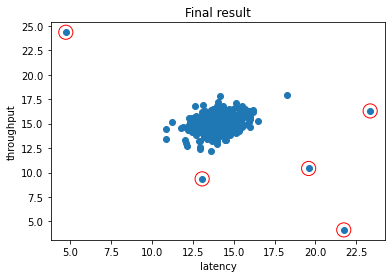

In [82]:
an=[]
for i in anom:
    an.append([X[i,0],X[i,1]])
an=np.array(an)
plt.scatter(X[:,0], X[:,1])
plt.scatter(an[:,0], an[:,1], s=200, facecolors='none', edgecolors='r')
plt.xlabel('latency')
plt.ylabel('throughput')
plt.title('Final result')